# Task 1 — Movie Genre Classification
**CodSoft Machine Learning Internship**

Goal: predict a movie's genre from its plot summary using TF-IDF features and
classic ML classifiers (Naive Bayes, Logistic Regression, Linear SVM).

**Before running:** download `train_data.txt` from the dataset link in the
CodSoft task PDF and place it in this same folder.

# New Section

In [13]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

pd.set_option("display.max_colwidth", 80)

## 1. Load the data
The dataset ships as a `:::`-delimited text file with columns
`ID`, `TITLE`, `GENRE`, `DESCRIPTION` (no header row).

In [2]:
train_data = pd.read_csv(
    "train_data.txt",
    sep=":::",
    engine="python",
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"],
)

print("Shape:", train_data.shape)
train_data.head()

Shape: (3178, 4)


,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,"Listening in to a conversation between his doctor and parents, 10-year-old ..."
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous relationship have a current mur...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their field trip to the Museum of Natur...
3,4,The Secret Sin (1915),drama,"To help their unemployed father make ends meet, Edith and her twin sister G..."
4,5,The Unrecovered (2007),drama,"The film's title refers not only to the un-recovered bodies at ground zero,..."


## 2. Quick EDA
How many genres are there, and how balanced are they?

In [3]:
print("Number of unique genres:", train_data["GENRE"].nunique())
train_data["GENRE"].value_counts()

Number of unique genres: 27


,count
GENRE,
drama,799
documentary,749
comedy,441
short,315
horror,129
thriller,112
action,80
reality-tv,60
western,59


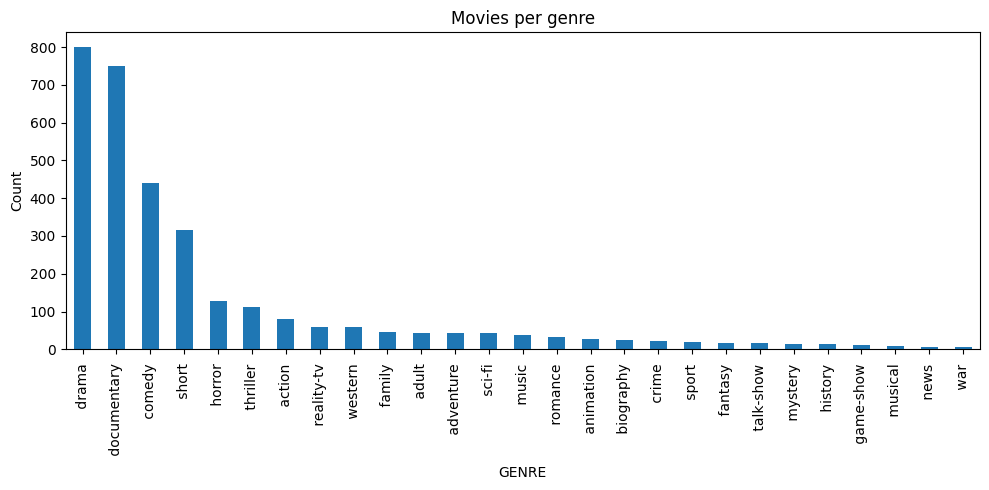

In [4]:
plt.figure(figsize=(10, 5))
train_data["GENRE"].value_counts().plot(kind="bar")
plt.title("Movies per genre")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("genre_distribution.png", dpi=100)
plt.show()

The genres are quite imbalanced (drama/documentary dominate). Keep this in
mind when reading the per-class scores below — rare genres will naturally
score lower.

## 3. Clean the text
Lowercase, strip punctuation/numbers, collapse whitespace. Nothing fancy —
TF-IDF does most of the heavy lifting.

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


train_data["DESCRIPTION_CLEAN"] = train_data["DESCRIPTION"].apply(clean_text)
train_data[["DESCRIPTION", "DESCRIPTION_CLEAN"]].head(3)

,DESCRIPTION,DESCRIPTION_CLEAN
0,"Listening in to a conversation between his doctor and parents, 10-year-old ...",listening in to a conversation between his doctor and parents year old oscar...
1,A brother and sister with a past incestuous relationship have a current mur...,a brother and sister with a past incestuous relationship have a current murd...
2,As the bus empties the students for their field trip to the Museum of Natur...,as the bus empties the students for their field trip to the museum of natura...


## 4. Train / validation split
We hold out 20% of the labeled training file to validate on, since the
official `test_data.txt` doesn't ship with genre labels.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    train_data["DESCRIPTION_CLEAN"],
    train_data["GENRE"],
    test_size=0.2,
    random_state=42,
    stratify=train_data["GENRE"],
)
print("Train size:", X_train.shape[0], "| Validation size:", X_val.shape[0])

Train size: 2542 | Validation size: 636


## 5. TF-IDF vectorization

In [7]:
tfidf = TfidfVectorizer(max_features=15000, stop_words="english", ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
print("TF-IDF matrix shape:", X_train_tfidf.shape)

TF-IDF matrix shape: (2542, 15000)


## 6. Train models
We try two classifiers the task suggests and compare them: Multinomial Naive
Bayes (fast, classic baseline for text) and Logistic Regression (usually
stronger on TF-IDF features).

In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_val_tfidf)

print("Naive Bayes accuracy:", accuracy_score(y_val, nb_preds))

Naive Bayes accuracy: 0.44025157232704404


In [9]:
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_val_tfidf)

print("Logistic Regression accuracy:", accuracy_score(y_val, lr_preds))

Logistic Regression accuracy: 0.4889937106918239


## 7. Evaluate the better model in detail

In [10]:
best_preds = lr_preds if accuracy_score(y_val, lr_preds) >= accuracy_score(y_val, nb_preds) else nb_preds
best_name = "Logistic Regression" if best_preds is lr_preds else "Naive Bayes"
print(f"Best model: {best_name}\n")
print(classification_report(y_val, best_preds, zero_division=0))

Best model: Logistic Regression

               precision    recall  f1-score   support

      action        0.21      0.31      0.25        16
       adult        0.50      0.56      0.53         9
   adventure        0.20      0.25      0.22         8
   animation        0.00      0.00      0.00         5
   biography        0.00      0.00      0.00         5
      comedy        0.59      0.41      0.48        88
       crime        0.00      0.00      0.00         5
 documentary        0.68      0.77      0.72       150
       drama        0.65      0.45      0.53       160
      family        0.21      0.30      0.25        10
     fantasy        0.00      0.00      0.00         3
   game-show        0.00      0.00      0.00         2
     history        0.00      0.00      0.00         3
      horror        0.49      0.69      0.57        26
       music        0.24      0.71      0.36         7
     musical        0.00      0.00      0.00         2
     mystery        0.00      0

## 8. Try it on a custom plot summary
Good cell to show live in your demo video.

In [11]:
sample_plot = [
    "A young wizard discovers he has magical powers and attends a school "
    "of witchcraft, where he must confront a dark lord threatening the world."
]
sample_clean = [clean_text(t) for t in sample_plot]
sample_tfidf = tfidf.transform(sample_clean)
predicted_genre = lr_model.predict(sample_tfidf)
print("Predicted genre:", predicted_genre[0])

Predicted genre:  fantasy 


## 9. Save the model + vectorizer

In [12]:
joblib.dump(lr_model, "movie_genre_model.joblib")
joblib.dump(tfidf, "tfidf_vectorizer.joblib")
print("Saved movie_genre_model.joblib and tfidf_vectorizer.joblib")

Saved movie_genre_model.joblib and tfidf_vectorizer.joblib


## Conclusion
A TF-IDF + Logistic Regression pipeline gives a solid baseline for genre
classification from plot text alone. Next steps you could mention in your
video/README: try word embeddings (Word2Vec/GloVe), balance rare genres with
oversampling, or fine-tune a small transformer for a stronger score.